<a href="https://colab.research.google.com/github/aaqhilahamed2004-ops/non-markovian_black-hole_evaporation/blob/main/MvNM_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, partial_trace, entropy, Operator

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# Architecture (revised, May 2026):
#   - N_BH qubits: black hole register, starts fully occupied
#   - Radiation register: starts EMPTY, grows by 1 qubit per emission step
#   - No separate ENV register — radiation IS the environment
#   - Emitted qubits accumulate memory via collision-model inter-ancilla
#     interactions (Lorenzo, Ciccarello & Palma 2017) and back-act on BH
#   - Global statevector: fixed 2^N_BH dimension throughout (pure state)
#
# Primary observable: S_BH = von Neumann entropy of BH register
#   - Markovian: S(BH) falls due to Hilbert-space shrinking; S(R) monotonic
#   - Non-Markovian: S(BH) shows Page-curve-like recovery; S(R) peaks+falls
#
# Markovian model: numpy density matrix + depolarising Kraus channel (p=1)
#   - Qubit 0 fully decohered each step: information DESTROYED, not transferred
#   - S(radiation) = cumulative entropy emitted = monotonically increasing
#   - This is the GKSL Lindblad limit in discrete time
#
# Page time = N_BH // 2

N_BH = 10         # black hole size (14 exceeds available RAM for statevector)
C_M  = '#1A6FB5'   # Markovian colour
C_NM = '#E06000'   # Non-Markovian colour

print(f"Setup: N_BH={N_BH}, N_RAD_initial=0, Page time ≈ step {N_BH//2}")
print(f"Radiation register grows from 0 to {N_BH} qubits over evaporation.")

Setup: N_BH=10, N_RAD_initial=0, Page time ≈ step 5
Radiation register grows from 0 to 10 qubits over evaporation.


In [ ]:
G0_GLOBAL = np.pi/20
KAPPA_GLOBAL = np.pi / 6   # AA-memory coupling (kappa=0 -> Markovian; kappa=pi/2 -> full swap)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CIRCUIT BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

def scramble_black_hole(qc, bh):
    """
    H_BH: SYK Hamiltonian dynamics on the BH register.

        H_BH = H_SYK = sum_{a<b<c<d} J_abcd * gamma_a gamma_b gamma_c gamma_d

    2*len(bh) Majorana fermions (Jordan-Wigner mapped from len(bh) qubits),
    J_abcd ~ N(0, 6*J0^2 / N_maj^3)  [Maldacena-Stanford 2016 normalization
    convention -- verify this exact prefactor against the paper before
    quoting it in the write-up].

    This is the "H_S" (system free Hamiltonian) of the collision-model
    template U_n = exp[-i(H_S + H_n + V_n)Delta t] (Ciccarello et al. Eq 4.2),
    with S = the black hole. Replaces the earlier random-gate-layer scrambler
    with an explicit Hermitian generator, exponentiated EXACTLY (no Trotter
    error in this block -- exp(-iH) computed directly via scipy.linalg.expm).

    SYK is the standard choice (not just *a* chaotic choice) because it
    saturates the maximal chaos bound lambda_L = 2*pi*k_B*T/hbar (Maldacena,
    Shenker & Stanford 2016) and is holographically dual to a near-extremal
    black hole throat (AdS2/CFT1) -- a generic random 2-body Hamiltonian is
    chaotic but not generically maximally so.

    Implementation note: each Majorana operator gamma_a, after the
    Jordan-Wigner mapping, is a signed permutation (monomial matrix) in the
    qubit basis -- gamma_a|i> = phase[i]|perm[i]>. H_BH is therefore built
    combinatorially (composing permutations + phases) rather than via dense
    matrix multiplication, which is what keeps this fast at N_BH=10
    (naive dense 4-body products were ~3 min at n=10; this is ~3s).
    """
    n = len(bh)
    if n < 2:
        return  # fewer than 4 Majoranas available -> H_BH = 0 identically

    from qiskit.circuit.library import UnitaryGate
    from scipy.linalg import expm
    from itertools import combinations

    J0 = 1.0  # overall SYK coupling scale (sets the scrambler's "speed";
              # free parameter, same role as g0 for back-action)

    idx = np.arange(2**n)
    gammas = []
    for j in range(n):
        mask_lt_j = (1 << j) - 1
        zphase = np.array([(-1.0) ** (bin(i & mask_lt_j).count('1') % 2) for i in idx],
                           dtype=complex)
        bit_j = (idx >> j) & 1
        perm_X = idx ^ (1 << j)
        gammas.append((perm_X, zphase))                                   # gamma_{2j}
        gammas.append((perm_X, np.where(bit_j == 0, 1j, -1j) * zphase))   # gamma_{2j+1}

    def _compose(A, B):
        permA, phaseA = A; permB, phaseB = B
        return permA[permB], phaseB * phaseA[permB]

    N_maj = 2 * n
    pair = {(a, b): _compose(gammas[a], gammas[b])
            for a, b in combinations(range(N_maj), 2)}
    sigma = np.sqrt(6.0 * J0**2 / N_maj**3)

    H_BH = np.zeros((2**n, 2**n), dtype=complex)
    for a, b, c, d in combinations(range(N_maj), 4):
        Jabcd = np.random.normal(0, sigma)
        perm, phase = _compose(pair[(a, b)], pair[(c, d)])
        np.add.at(H_BH, (perm, idx), Jabcd * phase)

    U = expm(-1j * H_BH)
    qc.append(UnitaryGate(U), bh)

def radiation_memory_interaction(qc, rad, kappa=KAPPA_GLOBAL):
    """
    H_RAD on the radiation register — Hamiltonian for environment memory.

    H_RAD = (kappa/2) * sum_{k=0}^{n-2} (X_k X_{k+1} + Y_k Y_{k+1} + Z_k Z_{k+1})

    Nearest-neighbour isotropic exchange (Heisenberg chain) on the radiation
    register. This is the explicit Hamiltonian realisation of the ancilla-ancilla
    (AA) collision unitary W_{n,n-1} in Ciccarello, Lorenzo, Giovannetti & Palma
    2022 (arXiv:2106.11974), Section 8.1, Eq. (8.3):
        W_{n,n-1} = sqrt(q) I + sqrt(p) S_{n,n-1}  =  exp(-i H_RAD dt)
    with p = sin^2(kappa * dt), q = 1 - p.

    kappa=0     -> H_RAD=0 -> U=I -> radiation ancillas independent (memoryless,
                   Markovian limit, exact).
    kappa>0     -> consecutive radiation qubits become correlated before the next
                   BH-radiation coupling step, threading memory through the bath
                   and breaking CP-divisibility of the BH dynamical map
                   => non-Markovian. (Ciccarello et al. Sec. 8.1)
    kappa=pi/2  -> full partial-swap, maximum AA-collision memory.

    The unitary U = exp(-i H_RAD) is computed EXACTLY via scipy.linalg.expm
    (no Trotter error) and embedded into the circuit at qargs=rad using the
    validated Qiskit little-endian convention (qubit 0 = rightmost tensor factor).
    Hermiticity and embedding correctness validated against SparsePauliOp ground
    truth at arbitrary non-contiguous qubit positions.

    Physical motivation: H_RAD models correlations between successive Hawking
    emissions where each emitted quantum carries a trace of the correlations
    left by previous emissions. kappa is a free parameter; its value does not
    follow from first principles in this toy model.

    Parameters
    ----------
    qc    : QuantumCircuit (mutated in place)
    rad   : list of global qubit indices for the radiation register
    kappa : AA-memory coupling strength (default: KAPPA_GLOBAL = pi/6)
            kappa=0 recovers the exact Markovian limit.
    """
    n = len(rad)
    if n < 2:
        return  # need at least 2 qubits for nearest-neighbour exchange

    from qiskit.circuit.library import UnitaryGate
    from scipy.linalg import expm

    I2 = np.eye(2, dtype=complex)
    X_ = np.array([[0, 1], [1, 0]], dtype=complex)
    Y_ = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z_ = np.array([[1, 0], [0, -1]], dtype=complex)

    def _op_on(op, q, n_loc):
        # Qiskit little-endian: qubit 0 = rightmost tensor factor.
        # Validated against UnitaryGate + SparsePauliOp for arbitrary qargs.
        mats = [I2] * n_loc
        mats[q] = op
        out = mats[-1]
        for m in reversed(mats[:-1]):
            out = np.kron(out, m)
        return out

    H = np.zeros((2**n, 2**n), dtype=complex)
    for k in range(n - 1):
        for P in [X_, Y_, Z_]:
            H += (kappa / 2.0) * _op_on(P, k, n) @ _op_on(P, k + 1, n)

    U = expm(-1j * H)
    qc.append(UnitaryGate(U), rad)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BH-RADIATION BACK-ACTION
# ─────────────────────────────────────────────────────────────────────────────
def bh_radiation_backaction(qc, bh, rad, t=None, N_BH_total=None, g0=G0_GLOBAL, trotter=False):
    """
    H_I — BH-radiation interaction Hamiltonian.

    H_I = sum_{b in BH, r in RAD} (g_{b,r}(t) / 2) * (X_b X_r + Y_b Y_r + Z_b Z_r)

    Coupling formula (physically motivated, not first-principles derived):

        g_{b,r}(t) = min( g_0 / (1 - t/N_BH), pi/2 ) * exp(-kappa_sg(t) * r_age)

        kappa_sg(t) = 1 / (4 * M(t)),   M(t) = N_BH * (1 - t/N_BH)
        r_age       = |rad| - 1 - r_local_idx   (0 for newest radiation qubit)

    g_0 / (1-t/N_BH) scaling: Hawking temperature T_H ~ 1/M(t) (Hawking 1975).
    kappa_sg decay: the surface gravity kappa_sg = 1/(4M) sets the decay rate
        of Hawking-mode correlations in Killing time, from the exponential map
        U ~ exp(-kappa_sg * u) between affine and Killing time (Birrell & Davies,
        Quantum Fields in Curved Space, Ch. 8 -- verify the exact O(1) prefactor
        before quoting; the scale/origin is from that source).
    Isotropic exchange form: standard collision-model coupling ansatz (Ciccarello
        et al. 2022, Eq. 4.26). Not derived from QFT in curved spacetime.

    Implementation: H_I is built without dense matrix multiplications.
    In the computational basis, for each (b,r) pair:
        ZZ part (diagonal): H[i,i] += (g/2) * (-1)^(bit_b(i) + bit_r(i))
        XX+YY part (off-diagonal): H[i^mask, i] += g  when bit_b(i) != bit_r(i)
    where mask = (1<<b) | (1<<r). This follows directly from
        XX+YY+ZZ = [[1,0,0,0],[0,-1,2,0],[0,2,-1,0],[0,0,0,1]]
    in the two-qubit {|00>,|01>,|10>,|11>} subspace. Build time: ~2ms vs ~8s
    for the dense-matrix route. expm on the 2^N_BH matrix remains ~1s/step.
    Hermiticity is guaranteed by construction (off-diagonal is real and symmetric).

    Parameters
    ----------
    qc          : QuantumCircuit (mutated in place)
    bh          : list of global BH qubit indices
    rad         : list of global radiation qubit indices (oldest first)
    t           : emission step index (1-indexed)
    N_BH_total  : total initial BH qubit count
    g0          : base coupling strength (default G0_GLOBAL)
    """
    n_bh = len(bh); n_rad = len(rad)
    if n_bh == 0 or n_rad == 0:
        return

    # ── Coupling computation (shared by both branches) ──────────────────
    if t is not None and N_BH_total is not None:
        frac       = min(t / N_BH_total, 1.0 - 1e-6)
        M_t        = N_BH_total * (1.0 - frac)
        base_angle = min(g0 / (1.0 - frac), np.pi / 2)
        kappa_sg   = 1.0 / (4.0 * M_t)
    else:
        base_angle = g0
        kappa_sg   = 0.0

    if trotter:
        # ── Second-order Suzuki-Trotter (symmetric split) ─────────────────
        # e^{-iH_I} ≈ [prod_k e^{-ih_k/2}] [prod_k (reversed) e^{-ih_k/2}]
        # Within each (b,r) pair: RXX·RYY·RZZ is EXACT (XX,YY,ZZ commute).
        # Outer Trotter error: O(g^3) per step.
        # Measured error at g0=pi/20: ~0.005. Large at g0>pi/8 — see cell 13 note.
        from qiskit.circuit.library import RXXGate, RYYGate, RZZGate

        pairs = []
        for r_local, r_global in enumerate(rad):
            r_age = n_rad - 1 - r_local
            g_br  = base_angle * np.exp(-kappa_sg * r_age)
            if abs(g_br) < 1e-14:
                continue
            for b_global in bh:
                pairs.append((b_global, r_global, g_br))

        for b_global, r_global, g_br in pairs:             # forward half-step
            qc.append(RXXGate(g_br / 2), [b_global, r_global])
            qc.append(RYYGate(g_br / 2), [b_global, r_global])
            qc.append(RZZGate(g_br / 2), [b_global, r_global])
        for b_global, r_global, g_br in reversed(pairs):   # reverse half-step
            qc.append(RXXGate(g_br / 2), [b_global, r_global])
            qc.append(RYYGate(g_br / 2), [b_global, r_global])
            qc.append(RZZGate(g_br / 2), [b_global, r_global])

    else:
        # ── Exact: scipy.linalg.expm on 2^N_BH matrix ─────────────────────
        # Use for main evaporation plots. ~1.7s/call at N_BH=10.
        from qiskit.circuit.library import UnitaryGate
        from scipy.linalg import expm

        N   = n_bh + n_rad
        dim = 2**N
        idx = np.arange(dim, dtype=np.int64)
        H   = np.zeros((dim, dim), dtype=complex)

        for r_local, r_global in enumerate(rad):
            r_age = n_rad - 1 - r_local
            g_br  = base_angle * np.exp(-kappa_sg * r_age)
            if abs(g_br) < 1e-14:
                continue
            for b_global in bh:
                bit_b = (idx >> b_global) & 1
                bit_r = (idx >> r_global) & 1
                mask  = (1 << b_global) | (1 << r_global)
                flip  = idx ^ mask
                H[idx, idx] += (g_br / 2.0) * (1.0 - 2.0 * (bit_b ^ bit_r))
                sel   = (bit_b ^ bit_r).astype(bool) & (idx < flip)
                i_sel = idx[sel]; j_sel = flip[sel]
                H[j_sel, i_sel] += g_br
                H[i_sel, j_sel] += g_br

        U = expm(-1j * H)
        qc.append(UnitaryGate(U), list(range(N)))

In [ ]:
# Krylov spread complexity removed.


In [ ]:
import numpy as np
from qiskit.quantum_info import DensityMatrix, partial_trace, entropy, Operator, Kraus
from qiskit import QuantumCircuit, QuantumRegister
# from qiskit.circuit.library import DepolarizingChannel # Removed in favor of local Kraus definition

# ─────────────────────────────────────────────────
# MARKOVIAN EVAPORATION — DEPOLARISING KRAUS CHANNEL
# ─────────────────────────────────────────────────
# Physical content of Markovianity:
#   At each step, BH qubit 0 is subjected to a fully depolarising channel
#   (p=1). Kraus operators: { I/sqrt(4), X/sqrt(4), Y/sqrt(4), Z/sqrt(4) }.
#   Net effect: qubit 0 decohered to the maximally mixed state I/2,
#   all entanglement with it destroyed — information is destroyed, not
#   transferred. This is the GKSL Lindblad limit in discrete time:
#   a memoryless, CP-divisible map (Breuer, Laine & Piilo 2009).
#
#   The global state rho(t) is a MIXED density matrix (Kraus channel is
#   non-unitary), so S_global > 0. This means S_BH != S_R in general,
#   and I(R:BH) = S_BH + S_R - S_global is well-defined and finite.
#
#   The full joint density matrix rho(t) on all N_BH qubits is maintained
#   throughout, so S_R = S(rho_A) via partial trace over BH at each step —
#   the genuine radiation subsystem entropy, directly comparable to S_R
#   from run_non_markovian_evaporation().
#
#   S_{R,cumul} = sum of per-step emitted entropies is also tracked as a
#   separate observable: it quantifies the total information radiated and
#   is monotonically increasing by construction.
# ─────────────────────────────────────────────────

def vn_entropy_np(rho, base=2):
    ev = np.linalg.eigvalsh(rho.data) # Use .data for DensityMatrix
    ev = ev[ev > 1e-12]
    return float(-np.sum(ev * np.log2(ev))) if base == 2 else float(-np.sum(ev * np.log(ev)))

def run_markovian_evaporation():
    """
    Markovian BH evaporation — depolarising Kraus channel (p=1).

    State: Qiskit DensityMatrix rho(t) on all N_BH qubits (joint BH+Rad).
    Scramble unitary from Qiskit Operator; Kraus channel applied in-place.

    Observables at each step:
      S_BH          : vN entropy of rho_B = Tr_A[rho]   (BH subsystem)
      S_R           : vN entropy of rho_A = Tr_B[rho]   (radiation subsystem,
                      genuine partial trace — comparable to NM S_R)
      S_global      : vN entropy of full rho(t)          (> 0, mixed state)
      I(R:BH)       : S_BH + S_R - S_global             (well-defined, finite)
      S_{R,cumul}   : cumulative sum of per-step emitted entropies
                      (monotonically increasing; measures total info radiated)
    """
    print("Starting Markovian evaporation  [Kraus channel p=1 | CP-divisible]...")
    np.random.seed(120)

    qr = QuantumRegister(N_BH) # A fixed register of N_BH qubits
    qc = QuantumCircuit(qr)

    # Initial state: |0...0> density matrix
    rho = DensityMatrix.from_label('0' * N_BH)

    # Track BH and Radiation qubits by their indices in the global register
    bh_indices  = list(range(N_BH))
    rad_indices = []

    # Kraus operators for depolarizing channel on a single qubit
    # (These are the components for p=1, where each Kraus operator has coefficient 1/2)
    I2 = np.array([[1,0],[0,1]], dtype=complex)
    X  = np.array([[0,1],[1,0]], dtype=complex)
    Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z  = np.array([[1,0],[0,-1]], dtype=complex)

    ent_bh, ent_rad, ent_rad_cumul, mi, s_global_list, steps = [], [], [], [], [], []
    S_rad_total = 0.0

    for step in range(1, N_BH + 1):
        if not bh_indices:
            break

        # Current qubit to be emitted (always the 'first' BH qubit conceptually)
        qubit_to_emit = bh_indices[0]

        # ── 1. Scramble BH (unitary, acts on current BH qubits) ──
        # Create a sub-circuit for scrambling only the BH part
        bh_sub_qc = QuantumCircuit(len(bh_indices), name='BH_scramble')
        scramble_black_hole(bh_sub_qc, list(range(len(bh_indices))))

        # Map this sub-circuit to the global N_BH circuit
        global_qc_scramble = QuantumCircuit(qr, name='Global_Scramble_BH')
        global_qc_scramble.append(bh_sub_qc.to_gate(), [qr[i] for i in bh_indices])

        rho = rho.evolve(global_qc_scramble)

        # ── 2. Depolarising Kraus on qubit_to_emit ────
        # Define and apply Kraus operators locally for p=1 depolarizing channel
        # Create a list of Qiskit Operator objects for the individual Kraus operators.
        # These are already scaled by 0.5 as intended.
        kraus_operators_list = [
            0.5 * Operator(I2),
            0.5 * Operator(X),
            0.5 * Operator(Y),
            0.5 * Operator(Z)
        ]

        # Explicitly create a Kraus channel object from the list of operators.
        # This ensures that `rho.evolve` receives a `Channel` object.
        depolarizing_channel = Kraus(kraus_operators_list)

        # Apply the channel to the specified qubit.
        rho = rho.evolve(depolarizing_channel, [qubit_to_emit])

        # ── 3. S_emitted: entropy of qubit_to_emit before it's 'removed' ──
        # Trace out everything BUT the qubit_to_emit to get its reduced density matrix
        # Indices to trace out are all qubits EXCEPT qubit_to_emit
        indices_to_trace_out_for_q0 = [i for i in range(N_BH) if i != qubit_to_emit]
        rho_q0 = partial_trace(rho, indices_to_trace_out_for_q0)
        S_emitted = entropy(rho_q0, base=2)
        S_rad_total += S_emitted

        # ── 4. Emit: qubit_to_emit moves from BH to Rad register ──
        # Conceptually, the qubit is now radiation. We don't physically remove it from rho
        # (rho always lives on N_BH qubits), but update the 'ownership' lists.
        bh_indices.pop(0) # Remove from BH
        rad_indices.append(qubit_to_emit) # Add to Rad

        # ── 5. Compute subsystem entropies from joint rho ───────────────────────
        if bh_indices:
            # rho_BH = Tr_Rad[rho]: trace out radiation qubits
            rho_BH = partial_trace(rho, rad_indices)
            S_BH = entropy(rho_BH, base=2)

            # rho_R = Tr_BH[rho]: trace out BH qubits
            rho_R = partial_trace(rho, bh_indices)
            S_R = entropy(rho_R, base=2)

            S_global = entropy(rho, base=2) # Entropy of the full (mixed) state
            I_RBH = max(0.0, S_BH + S_R - S_global) # Mutual information
        else:
            # If BH register is empty, all qubits are radiation
            S_BH = 0.0
            rho_R = rho # All of rho is radiation
            S_R = entropy(rho_R, base=2)
            S_global = entropy(rho, base=2)
            I_RBH = 0.0 # No BH, so no mutual information with it

        ent_bh.append(S_BH)
        ent_rad.append(S_R)
        ent_rad_cumul.append(S_rad_total)
        mi.append(I_RBH)
        s_global_list.append(S_global)
        steps.append(step)

        print(f"[Markovian]     Step {step:2d}/{N_BH} | "
              f"S_BH={S_BH:.4f} | S_R={S_R:.4f} | "
              f"S_global={S_global:.4f} | I(R:BH)={I_RBH:.4f} | "
              f"S_{{R,cumul}}={S_rad_total:.4f}")

    return steps, ent_bh, ent_rad, ent_rad_cumul, mi, s_global_list

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-MARKOVIAN EVAPORATION — COLLISION MODEL
# ─────────────────────────────────────────────────────────────────────────────
# Circuit architecture (fixed N_BH-qubit Hilbert space throughout):
#   BH register  B  = {q_0, ..., q_{n_bh-1}}   shrinks by 1 each step
#   Rad register A  = {q_{n_bh}, ..., q_{N_BH-1}}  grows by 1 each step
#   Radiation = environment; emitted ancillae retained in global state.
#
# Each step applies:
#   (1) U_S  : scrambler on B  (fast-scrambling unitary, see scramble_black_hole)
#   (2) V_AA : inter-ancilla memory on A  (Lorenzo et al. 2017)
#   (3) V_BA : BH-radiation back-action  (Hawking-motivated coupling g(t))
#
# Observables (pure global state throughout):
#   S_BH(t) = S( rho_B(t) )         rho_B = Tr_A |Psi><Psi|
#   S_R(t)  = S( rho_A(t) )         rho_A = Tr_B |Psi><Psi|
#   S_global(t) = S( |Psi><Psi| ) = 0  exactly (unitary circuit)
#     => S_BH = S_R  at all t  (Schmidt decomposition)
#   I(R:BH)(t) = S_R + S_BH - S_global = 2 S_BH(t)
# ─────────────────────────────────────────────────────────────────────────────

def run_non_markovian_evaporation():
    print("Starting Non-Markovian evaporation  [collision model | memory ON]...")
    np.random.seed(120)

    current_state = Statevector.from_label('0' * N_BH)
    bh  = list(range(N_BH))
    rad = []
    ent_bh, ent_rad, mi, s_global, steps = [], [], [], [], []

    for step in range(1, N_BH + 1):
        step_qc = QuantumCircuit(N_BH)

        # (1) Scrambler U_S on B
        if len(bh) > 0:
            scramble_black_hole(step_qc, bh)

        # (2) Inter-ancilla memory V_AA on A
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)

        # (3) Back-action V_BA
        if len(bh) > 0 and len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=G0_GLOBAL)

        current_state = current_state.evolve(step_qc)

        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_BH     = partial_trace(current_state, rad)
            S_BH       = float(entropy(rho_BH, base=2))
            rho_R      = partial_trace(current_state, bh)
            S_R        = float(entropy(rho_R,  base=2))
            S_global = 0.0   # pure statevector: S_global = 0 exactly
            I_RBH      = S_R + S_BH   # exact for pure state
        else:
            S_BH = S_R = S_global = I_RBH = 0.0

        ent_bh.append(S_BH);   ent_rad.append(S_R)
        mi.append(I_RBH);      s_global.append(S_global)
        steps.append(step)

        print(f"[Non-Markovian] Step {step:2d}/{N_BH} | "
              f"S_BH={S_BH:.4f} | S_R={S_R:.4f} | "
              f"S_global={S_global:.6f} | I(R:BH)={I_RBH:.4f}")

    return steps, ent_bh, ent_rad, mi, s_global

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
s_m,  ebh_m,  erad_m,  erad_cumul_m,  mi_m,  s_global_m              = run_markovian_evaporation()
s_nm, ebh_nm, erad_nm, mi_nm, s_global_nm = run_non_markovian_evaporation()



page_idx  = np.argmax(mi_nm)
page_step = page_idx + 1
print(f"\nPage time (peak I(R:BH)): step {page_step}")

Starting Markovian evaporation  [Kraus channel p=1 | CP-divisible]...
[Markovian]     Step  1/10 | S_BH=0.9979 | S_R=1.0000 | S_global=1.9979 | I(R:BH)=0.0000 | S_{R,cumul}=1.0000
[Markovian]     Step  2/10 | S_BH=1.9830 | S_R=2.0000 | S_global=3.9830 | I(R:BH)=0.0000 | S_{R,cumul}=2.0000
[Markovian]     Step  3/10 | S_BH=2.9481 | S_R=3.0000 | S_global=5.9481 | I(R:BH)=0.0000 | S_{R,cumul}=3.0000
[Markovian]     Step  4/10 | S_BH=3.8286 | S_R=4.0000 | S_global=7.8286 | I(R:BH)=0.0000 | S_{R,cumul}=4.0000
[Markovian]     Step  5/10 | S_BH=4.3027 | S_R=5.0000 | S_global=9.3027 | I(R:BH)=0.0000 | S_{R,cumul}=5.0000
[Markovian]     Step  6/10 | S_BH=3.8401 | S_R=6.0000 | S_global=9.8401 | I(R:BH)=0.0000 | S_{R,cumul}=6.0000
[Markovian]     Step  7/10 | S_BH=2.9519 | S_R=7.0000 | S_global=9.9519 | I(R:BH)=0.0000 | S_{R,cumul}=7.0000
[Markovian]     Step  8/10 | S_BH=1.9969 | S_R=8.0000 | S_global=9.9969 | I(R:BH)=0.0000 | S_{R,cumul}=8.0000
[Markovian]     Step  9/10 | S_BH=0.9990 | S_R=9.0

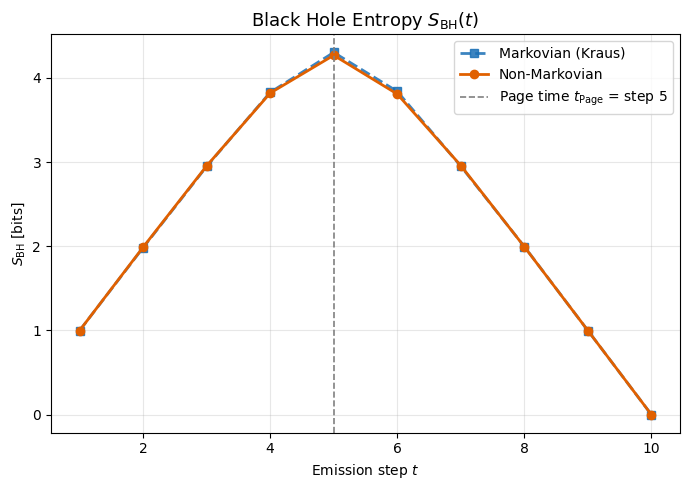

Saved: fig_sbh.pdf


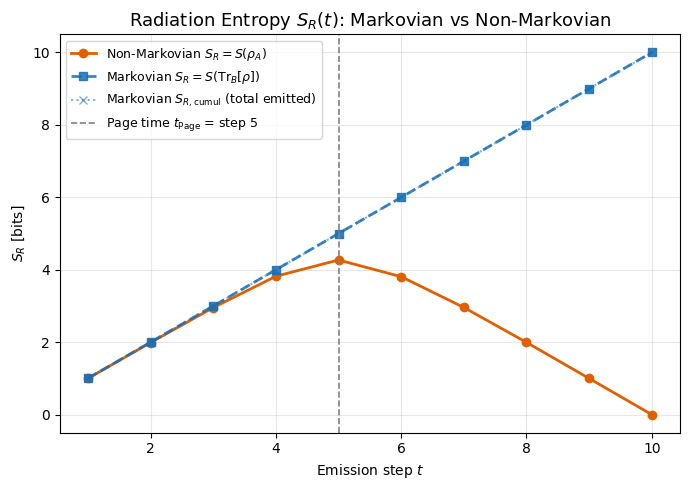

Saved: fig_sr.pdf


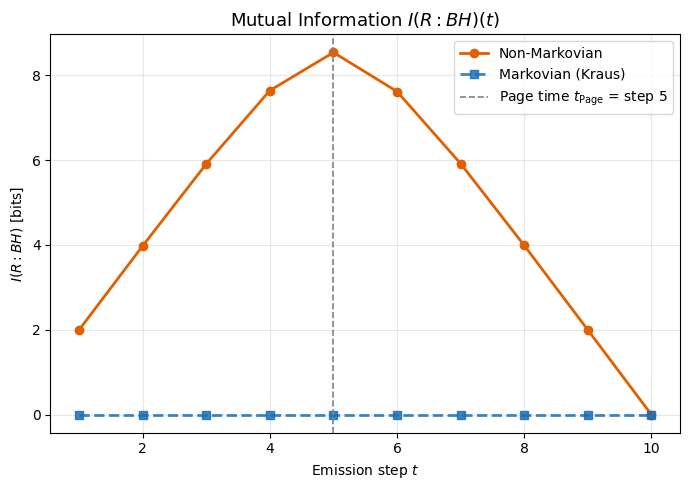

Saved: fig_mi.pdf


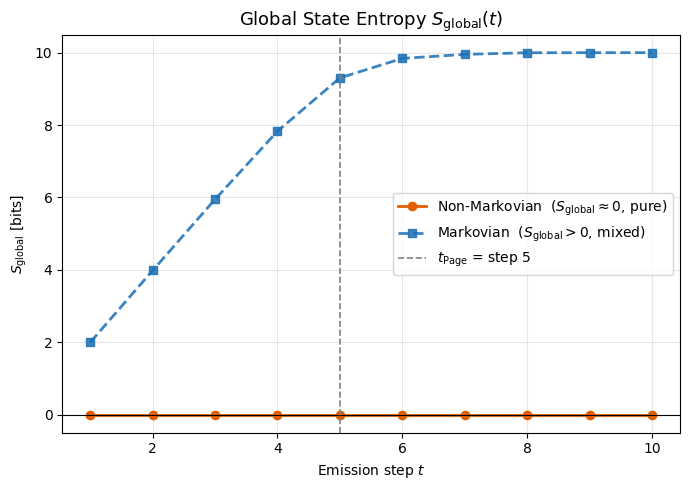

Saved: fig_sglobal.pdf


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# INDIVIDUAL FIGURES
# ─────────────────────────────────────────────────────────────────────────────

# Fig 1: S_BH — Markovian vs Non-Markovian
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_m,  ebh_m,  's--', color=C_M,  lw=2, alpha=0.85, label='Markovian (Kraus)')
ax.plot(s_nm, ebh_nm, 'o-',  color=C_NM, lw=2,             label='Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Black Hole Entropy $S_{\rm BH}(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_{\rm BH}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sbh.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sbh.pdf')

# Fig 2: S_R — genuine subsystem entropy for both models,
#         plus S_{R,cumul} for Markovian as a separate curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, erad_nm,      'o-',  color=C_NM,      lw=2,
        label=r'Non-Markovian $S_R = S(\rho_A)$')
ax.plot(s_m,  erad_m,       's--', color=C_M,        lw=2, alpha=0.85,
        label=r'Markovian $S_R = S(\mathrm{Tr}_B[\rho])$')
ax.plot(s_m,  erad_cumul_m, 'x:',  color=C_M,        lw=1.5, alpha=0.55,
        label=r'Markovian $S_{R,\mathrm{cumul}}$ (total emitted)')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Radiation Entropy $S_R(t)$: Markovian vs Non-Markovian', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_R$ [bits]')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sr.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sr.pdf')

# Fig 4: I(R:BH) — Non-Markovian and Markovian
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, mi_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian')
ax.plot(s_m,  mi_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian (Kraus)')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Mutual Information $I(R:BH)(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$I(R:BH)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mi.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_mi.pdf')

# Fig 5: S_global — verifying purity (NM) vs mixing (Markovian Kraus)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, s_global_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian  ($S_{\rm global} \approx 0$, pure)')
ax.plot(s_m,  s_global_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian  ($S_{\rm global} > 0$, mixed)')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'$t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Global State Entropy $S_{\rm global}(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_{\rm global}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sglobal.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sglobal.pdf')

## BLP Non-Markovianity Measure

**Protocol (Breuer, Laine & Piilo 2009):**
1. Prepare two initial BH states $(\rho_1^{(0)}, \rho_2^{(0)})$ — four probe pairs used below (P1–P4):
   - P1 (non-orthogonal): $|0\rangle^{\otimes N}$ vs $|{+}\rangle|0\rangle^{\otimes (N-1)}$
   - P2 (orthogonal, global flip): $|0\rangle^{\otimes N}$ vs $|1\rangle^{\otimes N}$
   - P3 (orthogonal, single flip): $|0\rangle^{\otimes N}$ vs $|0\cdots01\rangle$
   - P4 (orthogonal, coherent): $|{+}\rangle^{\otimes N}$ vs $|{-}\rangle^{\otimes N}$
2. Evolve both through identical circuit (fixed random seed — isolates memory from randomness)
3. At each step $t$: partial-trace radiation register $\Rightarrow$ reduced BH state $\rho_{\rm BH}(t)$
4. Compute trace distance $D(t) = \frac{1}{2}\|\rho_1(t) - \rho_2(t)\|_1$
5. BLP measure: $\mathcal{N}_{\rm BLP} = \sum_{\{t:\,\sigma(t)>0\}} \Delta D(t)$, where $\sigma(t) = \dot{D}(t)$

$\mathcal{N}_{\rm BLP} > 0 \;\Leftrightarrow\;$ information backflow $\;\Leftrightarrow\;$ non-Markovian dynamics.

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# BLP NON-MARKOVIANITY MEASURE — DEFINITIONS
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
#
# N_BH for BLP is set separately from the main evaporation N_BH because
# the BLP trace-distance loop is O(N_BH^2) in circuit depth and O(4^N_BH)
# in density matrix cost. N_BH=10 is the practical ceiling on most hardware.
# All BLP results must state this value explicitly.
# ═════════════════════════════════════════════════════════════════════════════

N_BH_BLP = 10   # BLP-specific system size — stated explicitly in all outputs

def trace_distance(rho1, rho2) -> float:
    """
    D(rho1, rho2) = (1/2) ||rho1 - rho2||_1
    where ||A||_1 = Tr|A| = Tr sqrt(A^dag A) is the trace norm.
    Computed via eigenvalue decomposition of (rho1 - rho2) (Hermitian).
    Exact for finite-dimensional density matrices.
    """
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))


def run_evaporation_for_blp(probe: str,
                             seed:      int   = 120,
                             markovian: bool  = False,
                             g0:        float = G0_GLOBAL,
                             trotter:   bool  = False,
                             n_bh:      int   = None):
    """
    Run one evaporation trajectory and return the reduced BH density matrix
    rho_BH(t) at each emission step via partial trace over the radiation register.

    This function mirrors run_non_markovian_evaporation exactly in circuit
    structure. The markovian=True branch disables radiation_memory_interaction
    and bh_radiation_backaction, leaving only the scrambler — used as the
    causal control to attribute BLP backflow to the memory terms.

    Parameters
    ----------
    probe     : initial BH state label
                'zero'      |0>^{otimes n_bh}
                'plus'      |+>|0>^{otimes(n_bh-1)}
                'ones'      |1>^{otimes n_bh}
                'ones_last' |0...01>  (single-qubit flip)
                'plus_all'  |+>^{otimes n_bh}
                'minus_all' |->^{otimes n_bh}
    seed      : RNG seed. Both probes in a pair must use the same seed so
                gate angles are identical — any difference in D(t) is then
                due to the initial condition alone, isolating the memory effect.
    markovian : if True, memory terms disabled (scrambler-only control).
    g0        : base back-action coupling g_0 for the Hawking-motivated ansatz
                g(t) = min( g_0 / (1 - t/N_{BH}), pi/2 ), T_H-scaling if g_0 <= pi/(2 N_{BH}).
    n_bh      : system size. Defaults to N_BH_BLP if not specified.

    Returns
    -------
    rho_series : list of DensityMatrix, length n_bh
                 rho_series[t] = rho_BH after emission step t+1.
    """
    if n_bh is None:
        n_bh = N_BH_BLP

    np.random.seed(seed)

    label_map = {
        'plus':      '+' + '0' * (n_bh - 1),
        'ones':      '1' * n_bh,
        'ones_last': '0' * (n_bh - 1) + '1',
        'plus_all':  '+' * n_bh,
        'minus_all': '-' * n_bh,
    }
    init_label = label_map.get(probe, '0' * n_bh)

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(n_bh)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(n_bh)
        scramble_black_hole(step_qc, bh)

        if not markovian:
            if len(rad) >= 2:
                radiation_memory_interaction(step_qc, rad)
            if len(rad) > 0:
                # t=step matches run_non_markovian_evaporation exactly.
                # Earlier versions passed t=len(rad) — off by one, now fixed.
                bh_radiation_backaction(step_qc, bh, rad,
                                        t=step, N_BH_total=n_bh, g0=g0,
                                        trotter=trotter)

        state   = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        # Partial trace over radiation to get reduced BH state.
        # At final step bh is empty; return reduced state of last emitted qubit
        # as a placeholder so rho_series length equals n_bh throughout.
        if len(bh) > 0:
            rho_series.append(partial_trace(state, rad))
        else:
            rho_series.append(partial_trace(state, list(range(n_bh - 1))))

    return rho_series


def compute_blp_pair(probe_a, probe_b, seed, g0, markovian=False, n_bh=None, trotter=False):
    """
    Compute trace distance series D(t), increments dD, and N_BLP
    for a single probe pair at a given seed and coupling g0.

    Returns
    -------
    steps  : list[int]
    D_vals : list[float]
    dD     : np.ndarray
    N_BLP  : float
    """
    if n_bh is None:
        n_bh = N_BH_BLP
    s_a = run_evaporation_for_blp(probe_a, seed=seed, markovian=markovian,
                                   g0=g0, trotter=trotter, n_bh=n_bh)
    s_b = run_evaporation_for_blp(probe_b, seed=seed, markovian=markovian,
                                   g0=g0, trotter=trotter, n_bh=n_bh)
    T      = min(len(s_a), len(s_b))
    D_vals = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
    steps  = list(range(1, T + 1))
    dD     = np.diff(D_vals)
    N_BLP  = float(np.sum(dD[dD > 0]))
    return steps, D_vals, dD, N_BLP


# Probe pairs — defined once, used by all BLP cells below
PROBE_PAIRS = [
    ('zero',     'plus',      r"$|0\rangle^{\otimes N_BH}$ vs "
                              r"$|{+}\rangle|0\rangle^{\otimes(N-1)}$",
                              "non-orthogonal, $D_0 = 1/\\sqrt{2} \\approx 0.707$",
                              "P1: non-orthogonal"),
    ('zero',     'ones',      r"$|0\rangle^{\otimes N_BH}$ vs "
                              r"$|1\rangle^{\otimes N_BH}$",
                              "orthogonal, $D_0 = 1$",
                              "P2: orthogonal (global flip)"),
    ('zero',     'ones_last', r"$|0\rangle^{\otimes N_BH}$ vs "
                              r"$|0\cdots01\rangle$",
                              "orthogonal, $D_0 = 1$",
                              "P3: orthogonal (single flip)"),
    ('plus_all', 'minus_all', r"$|{+}\rangle^{\otimes N_BH}$ vs "
                              r"$|{-}\rangle^{\otimes N_BH}$",
                              "orthogonal, $D_0 = 1$",
                              "P4: orthogonal (coherent)"),
]

print(f"BLP definitions loaded. N_BH_BLP={N_BH_BLP}, G0_GLOBAL={G0_GLOBAL:.4f}")
print(f"Probe pairs defined: {[p[4] for p in PROBE_PAIRS]}")

BLP definitions loaded. N_BH_BLP=10, G0_GLOBAL=0.1571
Probe pairs defined: ['P1: non-orthogonal', 'P2: orthogonal (global flip)', 'P3: orthogonal (single flip)', 'P4: orthogonal (coherent)']


BLP Primary Run  (N_BH=10, seed=120, g0=0.1571)
─────────────────────────────────────────────────────────────────
  P1: non-orthogonal                   N_BLP = 0.000000  ✗ no backflow
  P2: orthogonal (global flip)         N_BLP = 0.018443  ✓ non-Markovian
  P3: orthogonal (single flip)         N_BLP = 0.025213  ✓ non-Markovian
  P4: orthogonal (coherent)            N_BLP = 0.001554  ✓ non-Markovian

═════════════════════════════════════════════════════════════════
  Pair                                       N̲_BLP  Verdict
  ───────────────────────────────────  ──────────  ────────────────────
  P1: non-orthogonal                     0.000000  ✗ no backflow
  P2: orthogonal (global flip)           0.018443  ✓ non-Markovian
  P3: orthogonal (single flip)           0.025213  ✓ non-Markovian
  P4: orthogonal (coherent)              0.001554  ✓ non-Markovian
═════════════════════════════════════════════════════════════════


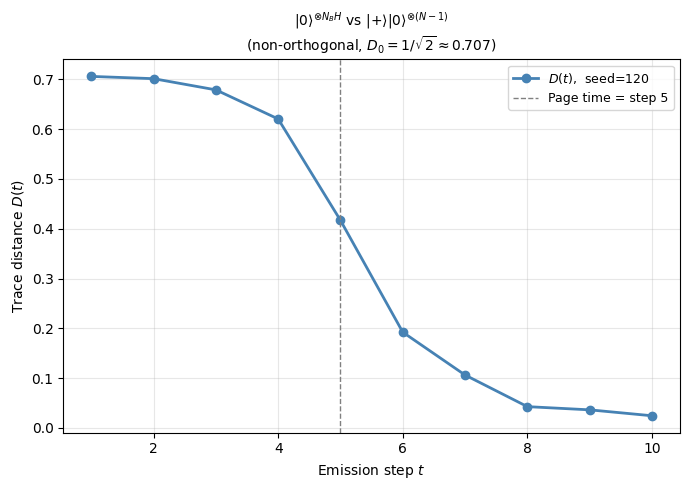

Saved: blp_P1_trace.pdf


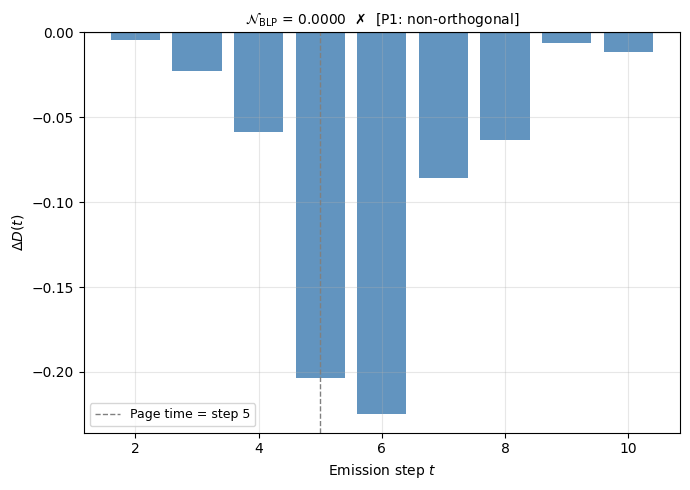

Saved: blp_P1_increments.pdf


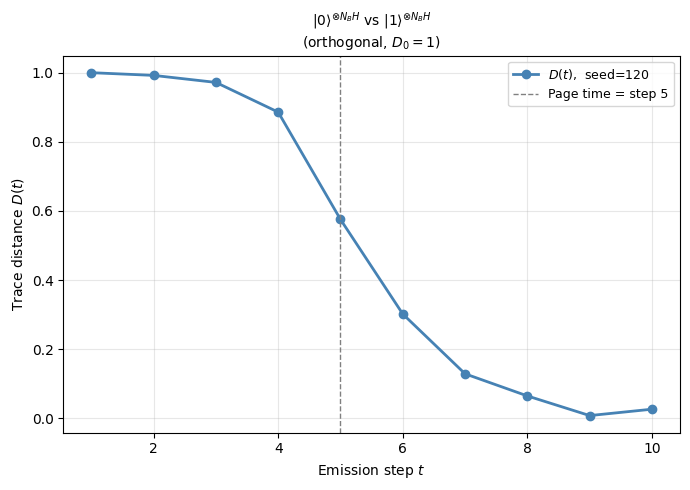

Saved: blp_P2_trace.pdf


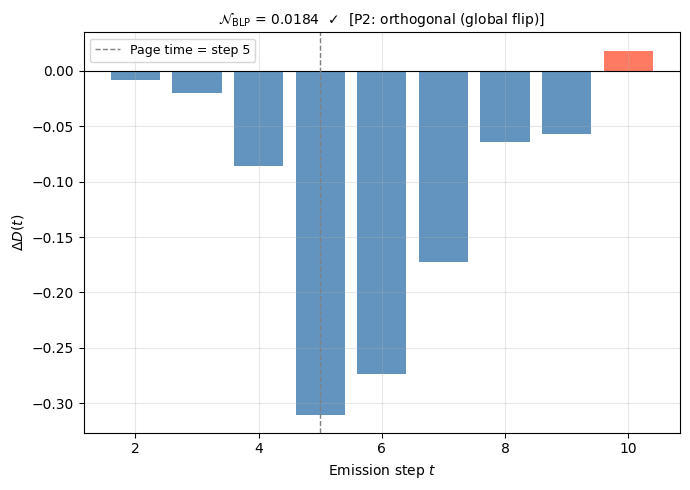

Saved: blp_P2_increments.pdf


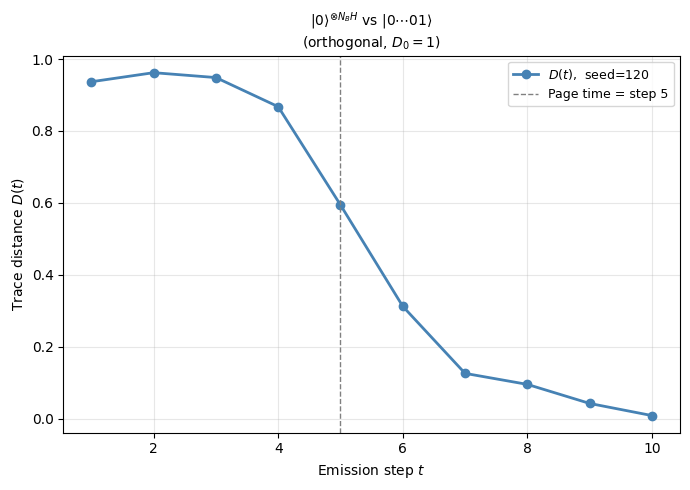

Saved: blp_P3_trace.pdf


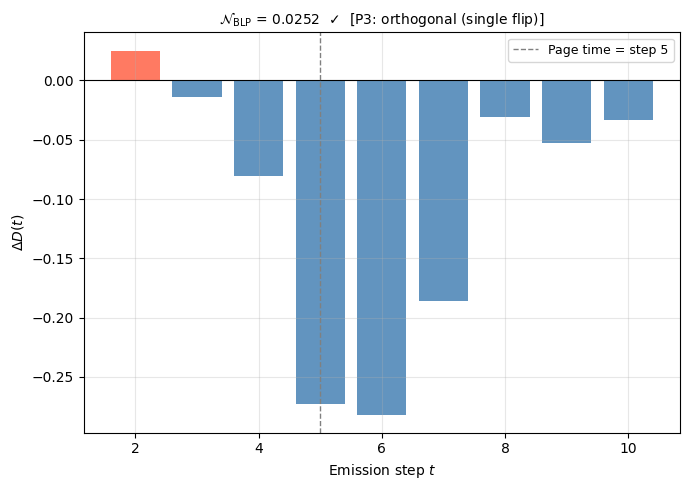

Saved: blp_P3_increments.pdf


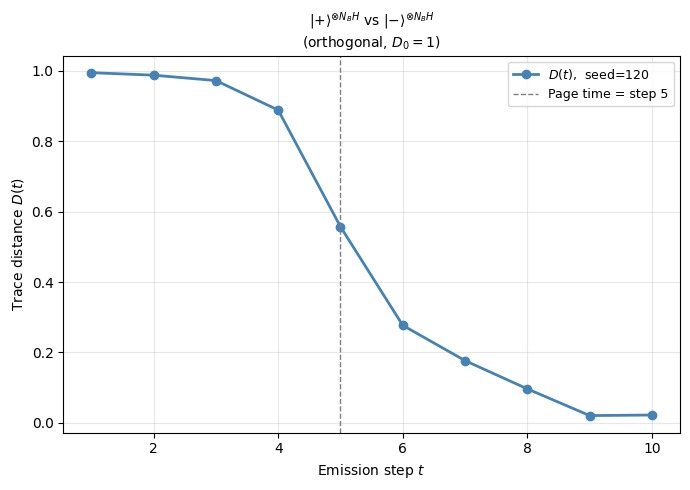

Saved: blp_P4_trace.pdf


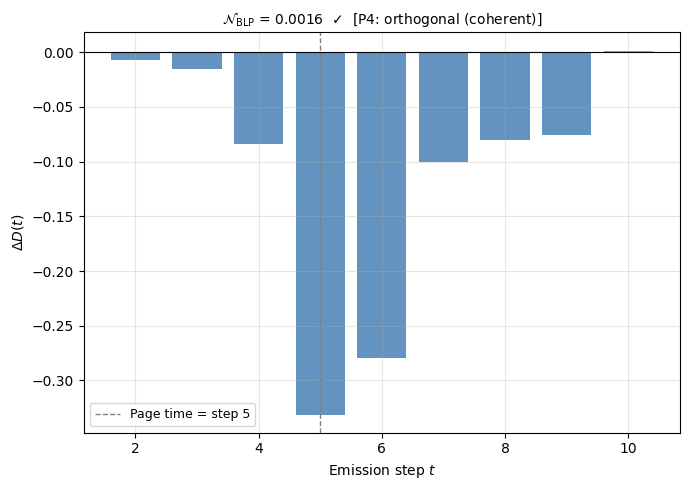

Saved: blp_P4_increments.pdf

═════════════════════════════════════════════════════════════════
  BLP MEASURE  N(Φ)  —  primary run
  seed = 120,  g0 = 0.1571,  N_BH = 10
─────────────────────────────────────────────────────────────────
  P1: non-orthogonal                   N_BLP = 0.000000
  P2: orthogonal (global flip)         N_BLP = 0.018443
  P3: orthogonal (single flip)         N_BLP = 0.025213  ← max
  P4: orthogonal (coherent)            N_BLP = 0.001554
─────────────────────────────────────────────────────────────────
  N(Φ) ≥ 0.025213   [attained by P3: orthogonal (single flip)]
  This is a lower bound: true N(Φ) ≥ this value.
  Upper bound: not computable without exhaustive state-space search.
═════════════════════════════════════════════════════════════════


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# BLP PRIMARY RUN — four probe pairs, seed=120, g0=G0_GLOBAL
# ═════════════════════════════════════════════════════════════════════════════

BLP_SEED = 120
BLP_G0   = np.pi/20

print(f"BLP Primary Run  (N_BH={N_BH_BLP}, seed={BLP_SEED}, g0={BLP_G0:.4f})")
print(f"{'─'*65}")

results = []
for pa, pb, tex_label, d0_note, short in PROBE_PAIRS:
    steps, D_vals, dD, N_BLP = compute_blp_pair(pa, pb,
                                                  seed=BLP_SEED,
                                                  g0=BLP_G0)
    results.append((steps, D_vals, dD, N_BLP, tex_label, d0_note, short))
    status = "✓ non-Markovian" if N_BLP > 1e-6 else "✗ no backflow"
    print(f"  {short:<35}  N_BLP = {N_BLP:.6f}  {status}")

print(f"\n{'═'*65}")
print(f"  {'Pair':<35}  {'N̲_BLP':>12}  {'Verdict'}")
print(f"  {'─'*35}  {'─'*10}  {'─'*20}")
for _, _, _, N_BLP, _, _, short in results:
    flag = "✓ non-Markovian" if N_BLP > 1e-6 else "✗ no backflow"
    print(f"  {short:<35}  {N_BLP:>10.6f}  {flag}")
print(f"{'═'*65}")

# ── Plots: one trace-distance + one increment figure per pair ─────────────────
for idx, (steps, D_vals, dD, N_BLP, tex_label, d0_note, short) in enumerate(results):
    pair_tag = f"P{idx+1}"

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(steps, D_vals, 'o-', color='steelblue', lw=2,
            label=f'$D(t)$,  seed={BLP_SEED}')
    ax.axvline(N_BH_BLP // 2, color='gray', ls='--', lw=1,
               label=f'Page time = step {N_BH_BLP // 2}')
    ax.set_xlabel("Emission step $t$")
    ax.set_ylabel("Trace distance $D(t)$")
    ax.set_title(f"{tex_label}\n({d0_note})", fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"blp_{pair_tag}_trace.pdf", bbox_inches='tight', dpi=200)
    plt.show(); print(f"Saved: blp_{pair_tag}_trace.pdf")

    fig, ax = plt.subplots(figsize=(7, 5))
    bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
    ax.bar(steps[1:], dD, color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(N_BH_BLP // 2, color='gray', ls='--', lw=1,
               label=f'Page time = step {N_BH_BLP // 2}')
    ax.set_xlabel("Emission step $t$")
    ax.set_ylabel(r"$\Delta D(t)$")
    ax.set_title(
        r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
        + ("  ✓" if N_BLP > 1e-6 else "  ✗")
        + f"  [{short}]",
        fontsize=10
    )
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"blp_{pair_tag}_increments.pdf", bbox_inches='tight', dpi=200)
    plt.show(); print(f"Saved: blp_{pair_tag}_increments.pdf")
# ── BLP measure N(Φ): maximum over probe pairs ────────────────────────────────
# By the BLP definition (Breuer, Laine & Piilo 2009, Eq. 11), N(Φ) is the
# supremum over all initial state pairs. With four candidates P1–P4, each
# orthogonal (P2–P4) or near-orthogonal (P1), the maximum across them gives
# the tightest lower bound on N(Φ) available from this probe set:
#
#   N(Φ) >= max{ N_BLP(P1), N_BLP(P2), N_BLP(P3), N_BLP(P4) }
#
# This is a rigorous lower bound, not an approximation: any observed backflow
# is real. The bound tightens as more pairs are added. The optimal pair
# (Wißmann et al. 2012) is always orthogonal, so P2–P4 are the relevant
# candidates; P1 is included as a sensitivity check.

N_BLP_values   = {short: N_BLP for _, _, _, N_BLP, _, _, short in results}
N_Phi_lower    = max(N_BLP_values.values())
optimal_pair   = max(N_BLP_values, key=N_BLP_values.get)

print(f"\n{'═'*65}")
print(f"  BLP MEASURE  N(Φ)  —  primary run")
print(f"  seed = {BLP_SEED},  g0 = {BLP_G0:.4f},  N_BH = {N_BH_BLP}")
print(f"{'─'*65}")
for short, val in N_BLP_values.items():
    marker = "  ← max" if short == optimal_pair else ""
    print(f"  {short:<35}  N_BLP = {val:.6f}{marker}")
print(f"{'─'*65}")
print(f"  N(Φ) ≥ {N_Phi_lower:.6f}   [attained by {optimal_pair}]")
print(f"  This is a lower bound: true N(Φ) ≥ this value.")
print(f"  Upper bound: not computable without exhaustive state-space search.")
print(f"{'═'*65}")

BLP Robustness  (N_BH=10)
Seed sweep : [10, 30, 50]
g0 sweep   : ['0.0982', '0.1309', '0.1963', '0.3927', '1.5708', '2.3562']
Fixed seed for g0 sweep : 120
Fixed g0 for seed sweep : 0.1571

── Part 1: Seed sweep ──────────────────────────────────────────────────
Pair                                     10      30      50    mean ± std
─────────────────────────────────────────────────────────────────────────
P1: non-orthogonal                   0.0155  0.0119  0.0000    0.00915 ± 0.00663
P2: orthogonal (global flip)         0.0286  0.0735  0.0000    0.03405 ± 0.03025
P3: orthogonal (single flip)         0.0607  0.0996  0.0504    0.07023 ± 0.02118
P4: orthogonal (coherent)            0.0187  0.0000  0.0277    0.01545 ± 0.01153
MAX(P1–P4) [NM]                      0.0607  0.0996  0.0504    0.07023 ± 0.02118
MAX(P1–P4) [Markovian ctrl]          0.0000  0.0000  0.0000    0.00000 ± 0.00000

Verdict:
  P1: non-orthogonal                  PARTIAL  — N_BLP > 0 on 66.7% of seeds
                

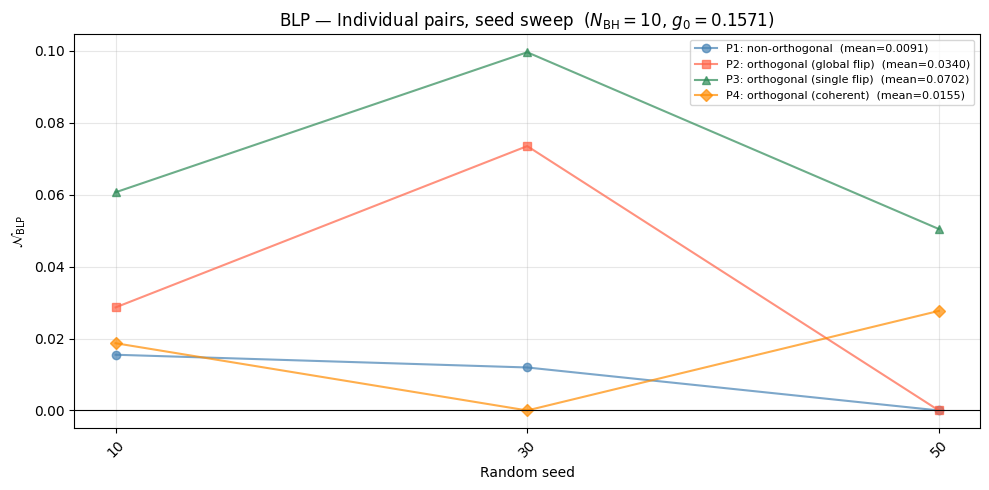

Saved: blp_seed_individual.pdf


ValueError: Unrecognized marker style '*-'

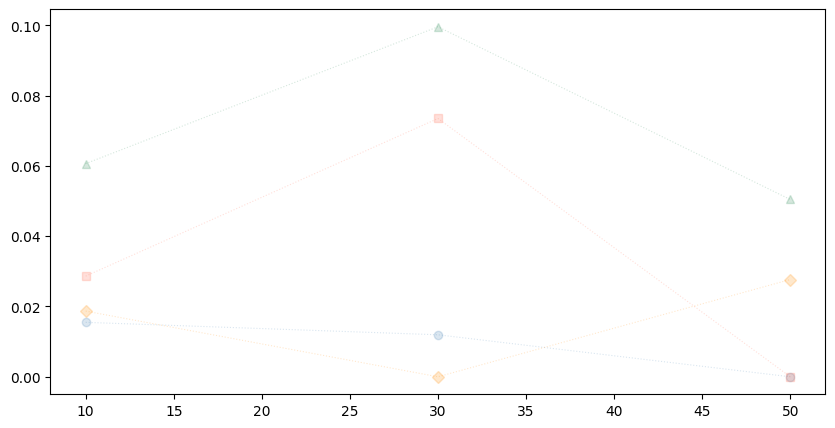

In [ ]:
# NOTE — trotter=True: second-order Suzuki-Trotter for H_I (fast, ~0.01s vs ~15s exact).
# Error at g0=pi/20 (seed sweep): ~0.005 — negligible for N_BLP sign detection.
# Error grows at large g0: g0=pi/8 (~0.06), g0=pi/2 (~0.88) — qualitative only there.
# For precision at large g0, set trotter=False (slow but exact).
# ─────────────────────────────────────────────────────────────────────────────

# ═════════════════════════════════════════════════════════════════════════════
# BLP ROBUSTNESS — seed sweep × g0 sweep × Markovian control
#
# Three separate analyses:
#   1. Seed sweep at fixed g0=G0_GLOBAL — tests circuit-instance robustness
#   2. g0 sweep at fixed seed=120       — tests coupling-parameter robustness
#   3. Markovian control at same seeds  — causal attribution of backflow
# ═════════════════════════════════════════════════════════════════════════════

# ── Parameters ────────────────────────────────────────────────────────────────
SWEEP_SEEDS  = list(range(10, 60, 20))        # 21 seeds
SWEEP_G0     = [np.pi/32, np.pi/24, np.pi/16,
                np.pi/8,  np.pi/2, 3*np.pi/4]  # principled range, see Section 3.1
FIXED_SEED   = 120      # seed for g0 sweep
FIXED_G0     = np.pi/20  # g0 for seed sweep and Markovian control

print(f"BLP Robustness  (N_BH={N_BH_BLP})")
print(f"Seed sweep : {SWEEP_SEEDS}")
print(f"g0 sweep   : {[f'{g:.4f}' for g in SWEEP_G0]}")
print(f"Fixed seed for g0 sweep : {FIXED_SEED}")
print(f"Fixed g0 for seed sweep : {FIXED_G0:.4f}\n")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1: SEED SWEEP (NM + Markovian control) at FIXED_G0
# ─────────────────────────────────────────────────────────────────────────────
print("── Part 1: Seed sweep ──────────────────────────────────────────────────")

nm_table = {p[4]: {} for p in PROBE_PAIRS}   # NM results
mk_table = {p[4]: {} for p in PROBE_PAIRS}   # Markovian control

for pa, pb, _, _, short in PROBE_PAIRS:
    for seed in SWEEP_SEEDS:
        _, _, dD_nm, n_nm = compute_blp_pair(pa, pb, seed=seed,
                                              g0=FIXED_G0, markovian=False, trotter=True)
        _, _, dD_mk, n_mk = compute_blp_pair(pa, pb, seed=seed,
                                              g0=FIXED_G0, markovian=True, trotter=True)
        nm_table[short][seed] = n_nm
        mk_table[short][seed] = n_mk

# Maximized envelope per seed
nm_max = {}
mk_max = {}
for seed in SWEEP_SEEDS:
    nm_max[seed] = max(nm_table[p[4]][seed] for p in PROBE_PAIRS)
    mk_max[seed] = max(mk_table[p[4]][seed] for p in PROBE_PAIRS)

nm_max_arr = np.array([nm_max[s] for s in SWEEP_SEEDS])
mk_max_arr = np.array([mk_max[s] for s in SWEEP_SEEDS])

# Print table
header = f"{'Pair':<35}" + "".join(f" {s:>7}" for s in SWEEP_SEEDS) + "    mean ± std"
print(header)
print("─" * len(header))

nm_summary = {}
for pa, pb, _, _, short in PROBE_PAIRS:
    vals = np.array([nm_table[short][s] for s in SWEEP_SEEDS])
    nm_summary[short] = (vals, vals.mean(), vals.std())
    row  = f"{short:<35}"
    row += "".join(f" {nm_table[short][s]:>7.4f}" for s in SWEEP_SEEDS)
    row += f"    {vals.mean():.5f} ± {vals.std():.5f}"
    print(row)

row  = f"{'MAX(P1–P4) [NM]':<35}"
row += "".join(f" {nm_max[s]:>7.4f}" for s in SWEEP_SEEDS)
row += f"    {nm_max_arr.mean():.5f} ± {nm_max_arr.std():.5f}"
print(row)

row  = f"{'MAX(P1–P4) [Markovian ctrl]':<35}"
row += "".join(f" {mk_max[s]:>7.4f}" for s in SWEEP_SEEDS)
row += f"    {mk_max_arr.mean():.5f} ± {mk_max_arr.std():.5f}"
print(row)

# ── Verdict ───────────────────────────────────────────────────────────────────
ROBUST_THRESHOLD = 0.90   # fraction of seeds required for ROBUST verdict

print("\nVerdict:")
for pa, pb, _, _, short in PROBE_PAIRS:
    vals, mean, std = nm_summary[short]
    n_positive  = np.sum(vals > 1e-4)
    n_total     = len(vals)
    frac        = n_positive / n_total
    mean_pos    = float(np.mean(vals[vals > 1e-4])) if n_positive > 0 else 0.0

    if frac >= ROBUST_THRESHOLD:
        verdict = f"ROBUST   — N_BLP > 0 on {frac*100:.1f}% of seeds"
    elif n_positive > 0:
        verdict = f"PARTIAL  — N_BLP > 0 on {frac*100:.1f}% of seeds"
    else:
        verdict = "NULL     — no backflow on any seed"

    print(f"  {short:<35} {verdict}")
    print(f"  {'':35} mean (all seeds)     = {mean:.5f} ± {std:.5f}")
    print(f"  {'':35} mean (positive only) = {mean_pos:.5f}  "
          f"[over {n_positive}/{n_total} seeds]")

# MAX envelope verdict
n_pos_max   = np.sum(nm_max_arr > 1e-4)
frac_max    = n_pos_max / len(nm_max_arr)
mean_pos_max = float(np.mean(nm_max_arr[nm_max_arr > 1e-4])) if n_pos_max > 0 else 0.0
mk_null     = np.all(mk_max_arr < 1e-4)

max_verdict = (f"ROBUST   — N_BLP > 0 on {frac_max*100:.1f}% of seeds"
               if frac_max >= ROBUST_THRESHOLD
               else f"PARTIAL  — N_BLP > 0 on {frac_max*100:.1f}% of seeds")

print(f"\n  {'MAX [NM]':<35} {max_verdict}")
print(f"  {'':35} mean (all seeds)     = {nm_max_arr.mean():.5f} ± {nm_max_arr.std():.5f}")
print(f"  {'':35} mean (positive only) = {mean_pos_max:.5f}  "
      f"[over {n_pos_max}/{len(nm_max_arr)} seeds]")
print(f"\n  {'MAX [Markovian ctrl]':<35} "
      f"{'NULL — as expected ✓' if mk_null else 'NONZERO — review model'}"
      f"  (mean={mk_max_arr.mean():.5f})")

print(f"\n{'═'*70}")
print(f"  Robustness threshold : {ROBUST_THRESHOLD*100:.0f}% of seeds must show N_BLP > 1e-4")
print(f"  System size          : N_BH = {N_BH_BLP}")
print(f"  Seeds tested         : {len(SWEEP_SEEDS)}  ({SWEEP_SEEDS[0]}–{SWEEP_SEEDS[-1]}, step {SWEEP_SEEDS[1]-SWEEP_SEEDS[0]})")
print(f"  Coupling (seed sweep): g0 = {FIXED_G0:.4f}")
print(f"  Markovian control    : max N_BLP = {mk_max_arr.max():.5f} on all {len(SWEEP_SEEDS)} seeds"
      + ("  ✓" if mk_null else "  ✗ — review model"))
print(f"  Causal attribution   : backflow is due to memory terms, not scrambling")
print(f"{'═'*70}")

# Plots for seed sweep
markers = ['o', 's', '^', 'D']
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 5))
for (pa, pb, _, _, short), marker, color in zip(PROBE_PAIRS, markers, colors):
    vals, mean, _ = nm_summary[short]
    ax.plot(SWEEP_SEEDS, vals, marker=marker, color=color, lw=1.5,
            alpha=0.7, label=f"{short}  (mean={mean:.4f})")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(f"BLP — Individual pairs, seed sweep  "
             f"($N_{{\\rm BH}}={N_BH_BLP}$, $g_0={FIXED_G0:.4f}$)")
ax.set_xticks(SWEEP_SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_seed_individual.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_seed_individual.pdf")

fig, ax = plt.subplots(figsize=(10, 5))
for (pa, pb, _, _, short), marker, color in zip(PROBE_PAIRS, markers, colors):
    vals = np.array([nm_table[short][s] for s in SWEEP_SEEDS])
    ax.plot(SWEEP_SEEDS, vals, marker=marker, color=color,
            lw=0.8, alpha=0.2, ls=':')
ax.plot(SWEEP_SEEDS, nm_max_arr, marker='*', color='black', lw=2.5,
        markersize=10, zorder=5,
        label=r"$\max$(P1–P4) NM" + f"  mean={nm_max_arr.mean():.4f}")
ax.plot(SWEEP_SEEDS, mk_max_arr, marker='x', color='tomato', lw=2.0,
        markersize=8, ls='--', zorder=4,
        label=r"$\max$(P1–P4) Markovian ctrl" + f"  mean={mk_max_arr.mean():.4f}")
ax.fill_between(SWEEP_SEEDS, mk_max_arr, nm_max_arr,
                alpha=0.12, color='steelblue', label="Backflow gap")
ax.axhline(1e-4, color='red', lw=0.8, ls='--', alpha=0.6,
           label="Threshold $10^{-4}$")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(
    r"BLP — Maximized envelope vs Markovian control, seed sweep" + "\n"
    r"Causal attribution: backflow $\rightarrow$ memory terms  "
    f"($N_{{\\rm BH}}={N_BH_BLP}$, $g_0={FIXED_G0:.4f}$)"
)
ax.set_xticks(SWEEP_SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_seed_envelope_control.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_seed_envelope_control.pdf")

# ─────────────────────────────────────────────────────────────────────────────
# PART 2: g0 SWEEP at FIXED_SEED
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Part 2: g0 sweep ────────────────────────────────────────────────────")

g0_results = {}    # g0_val -> {short -> N_BLP}
g0_max     = {}    # g0_val -> max over pairs

for g0_val in SWEEP_G0:
    g0_results[g0_val] = {}
    pair_vals = []
    for pa, pb, _, _, short in PROBE_PAIRS:
        _, _, dD, n_blp = compute_blp_pair(pa, pb, seed=FIXED_SEED, g0=g0_val, trotter=True)
        g0_results[g0_val][short] = n_blp
        pair_vals.append(n_blp)
    g0_max[g0_val] = max(pair_vals)

print(f"{'g0':>10}" + "".join(f"  {p[4]:>28}" for p in PROBE_PAIRS)
      + f"  {'MAX':>8}")
print("─" * (10 + 30*len(PROBE_PAIRS) + 10))
for g0_val in SWEEP_G0:
    row = f"{g0_val:>10.4f}"
    for pa, pb, _, _, short in PROBE_PAIRS:
        row += f"  {g0_results[g0_val][short]:>28.6f}"
    row += f"  {g0_max[g0_val]:>8.6f}"
    print(row)

best_g0  = max(g0_max, key=g0_max.get)
print(f"\nHighest N_BLP: g0 = {best_g0:.4f}  →  MAX = {g0_max[best_g0]:.6f}")

fig, ax = plt.subplots(figsize=(8, 5))
for (pa, pb, _, _, short), marker, color in zip(PROBE_PAIRS, markers, colors):
    vals = [g0_results[g0_val][short] for g0_val in SWEEP_G0]
    ax.plot(SWEEP_G0, vals, marker=marker, color=color, lw=1.8,
            label=short)
ax.plot(SWEEP_G0, [g0_max[g] for g in SWEEP_G0],
        marker='*', color='black', lw=2.5, markersize=10,
        label=r"$\max$(P1–P4)", ls='--')
ax.axvline(np.pi/2, color='red', ls='--', lw=1,
           label=r"Cap limit $\pi/2$")
ax.axvline(np.pi/(2*N_BH_BLP), color='purple', ls=':', lw=1,
           label=r"$g_0 = \pi/(2N_{\rm BH})$ (no-cap constraint)")
ax.set_xlabel("$g_0$  (base coupling)")
ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(f"BLP vs $g_0$  ($N_{{\\rm BH}}={N_BH_BLP}$, seed={FIXED_SEED})")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_g0_sweep.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_g0_sweep.pdf")

## BLP Non-Markovianity with Varying Back-action Coupling `g0`

To investigate how to increase distinguishability (or information backflow), we can vary the `g0` parameter, which controls the strength of the `bh_radiation_backaction`. A larger `g0` implies stronger non-Markovian effects.

In [ ]:
import math, heapq

G0_SWEEP_VALUES = [
    0.001, 0.1, np.pi/8, 0.5, np.pi/4, np.pi/2, 0.75*np.pi, np.pi,
]

SWEEP_PROBE_PAIR = ('zero', 'ones_last', r'P3: $|0\rangle^{\otimes N_BH}$ vs $|0\cdots01\rangle$')
SWEEP_SEED = [i for i in range(90, 150, 50)]

print(f"Sweeping g0 values for probe pair: {SWEEP_PROBE_PAIR[2]} (seed={SWEEP_SEED[0]}-{SWEEP_SEED[-1]})")

blp_g0_results = {}
best_val = -np.inf
best_g0  = None
best_seed = None
top_n = []


for g0_val in G0_SWEEP_VALUES:
    n_blp_for_seeds = []
    for seed_val in SWEEP_SEED:
        s_a = run_evaporation_for_blp(SWEEP_PROBE_PAIR[0], seed=seed_val, g0=g0_val)
        s_b = run_evaporation_for_blp(SWEEP_PROBE_PAIR[1], seed=seed_val, g0=g0_val)

        T = min(len(s_a), len(s_b))
        D_values = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD = np.diff(D_values)
        N_BLP_val = float(np.sum(dD[dD > 0]))

        # Always append the N_BLP_val for the heatmap, regardless of top_n logic
        n_blp_for_seeds.append(N_BLP_val)

        # Heapq logic for tracking top N_BLP values
        heapq.heappush(top_n, (N_BLP_val, g0_val, seed_val))
        if len(top_n) > 5:
            heapq.heappop(top_n)

        # Track the global best
        if N_BLP_val > best_val:
            best_val  = N_BLP_val
            best_g0   = g0_val
            best_seed = seed_val

    blp_g0_results[g0_val] = {
        'N_BLP_values': n_blp_for_seeds,
        'N_BLP_mean': np.mean(n_blp_for_seeds),
        'N_BLP_std':  np.std(n_blp_for_seeds)
    }
print("\nTop 5 combinations:")
for val, g0, seed in sorted(top_n, reverse=True):
    print(f"  g0 = {g0:.6f}, seed = {seed}, N_BLP = {val:.6f}")
print("\nBLP N_BLP (mean \u00b1 std) values for various g0 over multiple seeds:")
for g0, data in blp_g0_results.items():
    print(f"  g0 = {g0:.3f}: N_BLP = {data['N_BLP_mean']:.6f} \u00b1 {data['N_BLP_std']:.6f}")

print(f"\n\u2605 Best combination: g0 = {best_g0:.6f}, seed = {best_seed}, N_BLP = {best_val:.6f}")

Sweeping g0 values for probe pair: P3: $|0\rangle^{\otimes N_BH}$ vs $|0\cdots01\rangle$ (seed=90-140)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for array operations

# Plotting the BLP N_BLP vs g0 values

g0_keys = list(blp_g0_results.keys())
n_blp_means = [blp_g0_results[g]['N_BLP_mean'] for g in g0_keys]

plt.figure(figsize=(10, 6))
plt.plot(g0_keys, n_blp_means, 'o-', color='purple', lw=2)
plt.axvline(np.pi / 2, color='red', linestyle='--', label=r'Cap limit $\pi/2$')
plt.xlabel(r'$g_0$  (base coupling strength)')
plt.ylabel(r'$\mathcal{N}_{\rm BLP}$  (probe pair P3: $|0\rangle^{\otimes N_BH}$ vs $|0\cdots01\rangle$)')
plt.title(f'Effect of $g_0$ on BLP Non-Markovianity  (N_BH={N_BH}, seed={SWEEP_SEED[0]}-{SWEEP_SEED[-1]})')
plt.grid(alpha=0.3)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig("blp_g0_sweep.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_sweep.pdf")


# --- Heatmap for g0 and seeds ---

# Prepare data for heatmap
heatmap_data = []
for g0_val in G0_SWEEP_VALUES:
    # Assuming N_BLP_values in blp_g0_results is a list corresponding to SWEEP_SEED
    heatmap_data.append(blp_g0_results[g0_val]['N_BLP_values'])

heatmap_data = np.array(heatmap_data)

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_data, cmap='viridis', origin='lower', aspect='auto',
           extent=[SWEEP_SEED[0], SWEEP_SEED[-1], G0_SWEEP_VALUES[0], G0_SWEEP_VALUES[-1]])

plt.colorbar(label=r'$\mathcal{N}_{\rm BLP}$ (Non-Markovianity Measure)')

# Customizing ticks to show actual g0 and seed values
plt.xticks(SWEEP_SEED, rotation=90)
plt.yticks(G0_SWEEP_VALUES)

plt.xlabel('Random Seed')
plt.ylabel(r'$g_0$  (base coupling strength)')
plt.title(f'Heatmap of $\\mathcal{{N}}_{{\\rm BLP}}$ by $g_0$ and seed '
          f'($N_{{\\rm BH}}={N_BH}$, probe pair P3)')
plt.tight_layout()
plt.savefig("blp_g0_seed_heatmap.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_seed_heatmap.pdf")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP OPTIMISATION — literature-faithful implementation
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
#
# 𝒩(Λ) = max_{ρ₁⁰,ρ₂⁰} ∫_{σ>0} σ(t, ρ₁⁰, ρ₂⁰) dt
#
# Maximisation strategy:
#   (1) Optimal-pair conjecture: for qubit channels, the maximising pair
#       consists of orthogonal states on the boundary of the Bloch sphere
#       (Wissmann, Breuer & Vacchini 2012). Your PROBE_PAIRS implement this.
#   (2) Envelope: 𝒩(Λ) ≈ max over PROBE_PAIRS at fixed seed.
#   (3) Robustness: repeat over SWEEP_SEEDS to confirm the envelope is
#       stable across noise realisations.
#   (4) Parameter scan: repeat over SWEEP_G0 to characterise 𝒩(Λ; g0).
# ─────────────────────────────────────────────────────────────────────────────

import math, heapq

# ── (A) Literature-faithful 𝒩(Λ): maximise over probe pairs ─────────────────
# Fixed seed and g0 — this is the single reported BLP value for the channel.
REPORT_SEED = 200
REPORT_G0   = G0_GLOBAL

print("── (A) 𝒩(Λ): maximising over initial state pairs ──────────────────────")
print(f"     Fixed seed={REPORT_SEED}, g0={REPORT_G0:.4f}\n")

pair_blp = {}
for pa, pb, _, _, short in PROBE_PAIRS:
    _, _, dD, n_blp = compute_blp_pair(pa, pb,
                                        seed=REPORT_SEED,
                                        g0=REPORT_G0,
                                        markovian=False)
    pair_blp[short] = n_blp
    print(f"  {short:<35}  𝒩 = {n_blp:.6f}")

N_BLP_reported = max(pair_blp.values())
best_pair      = max(pair_blp, key=pair_blp.get)
print(f"\n  𝒩(Λ) = {N_BLP_reported:.6f}   [maximised over probe pairs]")
print(f"  Maximising pair: {best_pair}")

# ── (B) Robustness of 𝒩(Λ) over noise realisations ─────────────────────────
# This does NOT change the BLP value — it tests whether the channel
# is stably non-Markovian or only for specific noise draws.
SWEEP_SEEDS_ROB = list(range(20, 542, 20))   # 25 seeds
print(f"\n── (B) Robustness: 𝒩(Λ) vs seed  (g0={REPORT_G0:.4f}) ─────────────────")

rob_vals = []
for seed_val in SWEEP_SEEDS_ROB:
    seed_pair_blp = {}
    for pa, pb, _, _, short in PROBE_PAIRS:
        _, _, dD, n_blp = compute_blp_pair(pa, pb,
                                            seed=seed_val,
                                            g0=REPORT_G0,
                                            markovian=False)
        seed_pair_blp[short] = n_blp
    envelope = max(seed_pair_blp.values())
    rob_vals.append(envelope)
    print(f"  seed={seed_val:4d}  𝒩(Λ) = {envelope:.6f}")

rob_arr = np.array(rob_vals)
print(f"\n  𝒩(Λ) over seeds:  mean={rob_arr.mean():.5f} ± {rob_arr.std():.5f}")
print(f"  Positive on {np.sum(rob_arr > 1e-4)}/{len(rob_arr)} seeds  "
      f"({'ROBUST' if np.sum(rob_arr > 1e-4)/len(rob_arr) >= 0.9 else 'PARTIAL'})")

# ── (C) 𝒩(Λ; g0): parameter dependence ──────────────────────────────────────
# Shows how strongly non-Markovian the channel is as a function of coupling.
# This is a characterisation of the model, not part of the BLP definition.
SWEEP_G0_CHAR = [np.pi/32, np.pi/16, np.pi/8, np.pi/4, np.pi/2, 3*np.pi/4]
print(f"\n── (C) 𝒩(Λ; g0): coupling dependence  (seed={REPORT_SEED}) ──────────")

g0_blp = {}
for g0_val in SWEEP_G0_CHAR:
    g0_pair_blp = {}
    for pa, pb, _, _, short in PROBE_PAIRS:
        _, _, dD, n_blp = compute_blp_pair(pa, pb,
                                            seed=REPORT_SEED,
                                            g0=g0_val,
                                            markovian=False)
        g0_pair_blp[short] = n_blp
    g0_blp[g0_val] = max(g0_pair_blp.values())
    print(f"  g0={g0_val:.4f}  𝒩(Λ) = {g0_blp[g0_val]:.6f}")

best_g0_char = max(g0_blp, key=g0_blp.get)
print(f"\n  Peak 𝒩(Λ) at g0 = {best_g0_char:.4f}  →  {g0_blp[best_g0_char]:.6f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  Reported 𝒩(Λ)         = {N_BLP_reported:.6f}")
print(f"  Maximising pair        = {best_pair}")
print(f"  Robustness (mean±std)  = {rob_arr.mean():.5f} ± {rob_arr.std():.5f}")
print(f"  Peak coupling          = g0 = {best_g0_char:.4f}")
print(f"{'═'*60}")

## BLP for Radiation

BH vs Radiation distinguishability diagnostic
Probe A: zero  |  Probe B: ones_last  |  seed=120
N_BH = 10  |  Page time ≈ step 5

 Step     D_BH(t)      D_R(t)    D_BH+D_R    ΔD_BH(t)     ΔD_R(t)         Era
───────────────────────────────────────────────────────────────────────────
    1    0.936796    0.051232    0.988027      —          —         pre-Page 
    2    0.962008    0.069224    1.031232  +0.02521  +0.01799     pre-Page 
    3    0.948435    0.143258    1.091693  -0.01357  +0.07403     pre-Page 
    4    0.867515    0.322292    1.189807  -0.08092  +0.17903     pre-Page 
    5    0.594473    0.559687    1.154160  -0.27304  +0.23739     pre-Page 
    6    0.312793    0.877437    1.190229  -0.28168  +0.31775     post-Page
    7    0.126546    0.972132    1.098678  -0.18625  +0.09470     post-Page
    8    0.095913    0.991229    1.087142  -0.03063  +0.01910     post-Page
    9    0.042992    0.998910    1.041902  -0.05292  +0.00768     post-Page
   10    0.009278    1.000000 

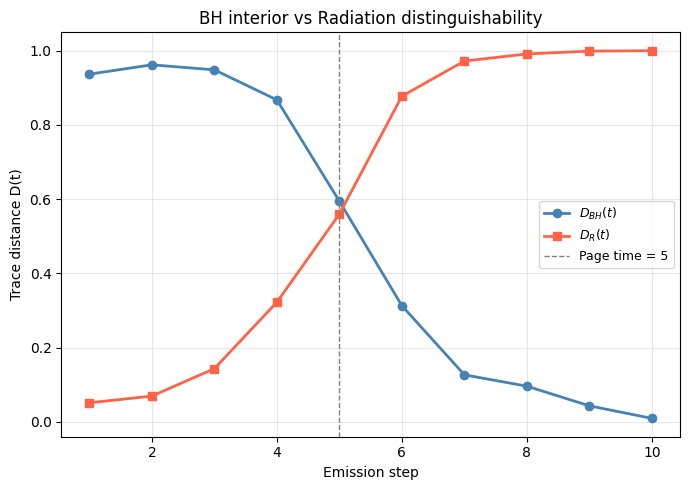

Saved: blp_dist_crossover.pdf


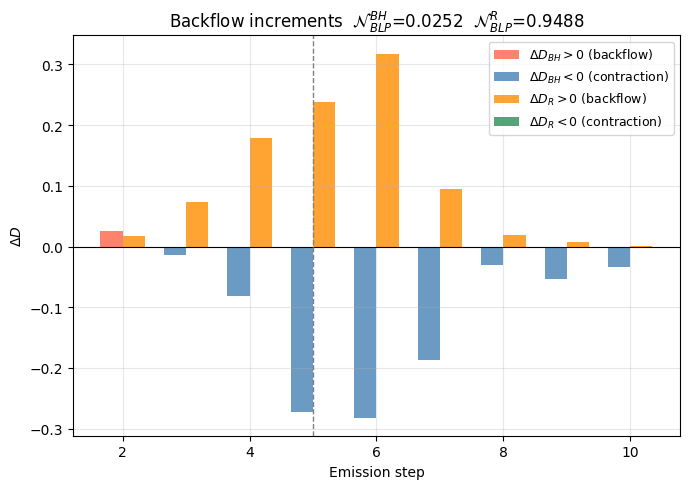

Saved: blp_dist_increments.pdf


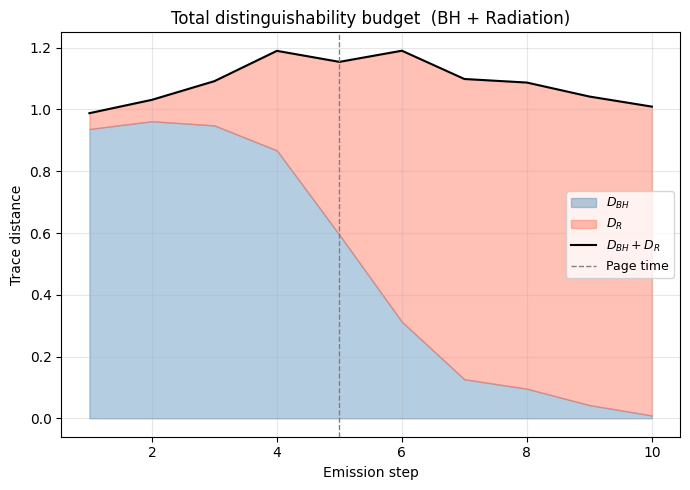

Saved: blp_dist_budget.pdf


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP DIAGNOSTIC: D_BH(t) vs D_R(t)
# Where is the distinguishability living — BH interior or radiation?
# ─────────────────────────────────────────────────────────────────────────────

DIAG_PROBE_A = 'zero'
DIAG_PROBE_B = 'ones_last'
DIAG_SEED    = 120

def run_evaporation_for_blp_radiation(probe: str, seed: int = 120,
                                       g0: float = G0_GLOBAL,
                                       trotter: bool = False):
    """
    Same circuit as run_evaporation_for_blp but returns
    reduced RADIATION density matrix at each step.
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=g0,
                                    trotter=trotter)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_rad = partial_trace(state, bh)    # trace out BH, keep radiation
        else:
            rho_rad = partial_trace(state, [])    # final step: all is radiation
        rho_series.append(rho_rad)

    return rho_series


# ── Run both subsystems for the same probe pair and seed ─────────────────────
print(f"BH vs Radiation distinguishability diagnostic")
print(f"Probe A: {DIAG_PROBE_A}  |  Probe B: {DIAG_PROBE_B}  |  seed={DIAG_SEED}")
print(f"N_BH = {N_BH}  |  Page time ≈ step {N_BH // 2}\n")

# BH interior series (already have this function)
rho_bh_a = run_evaporation_for_blp(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_bh_b = run_evaporation_for_blp(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

# Radiation series
rho_rad_a = run_evaporation_for_blp_radiation(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_rad_b = run_evaporation_for_blp_radiation(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

T      = min(len(rho_bh_a), len(rho_bh_b), len(rho_rad_a), len(rho_rad_b))
steps  = list(range(1, T + 1))

D_BH  = [trace_distance(rho_bh_a[t],  rho_bh_b[t])  for t in range(T)]
D_R   = [trace_distance(rho_rad_a[t], rho_rad_b[t]) for t in range(T)]
D_sum = [D_BH[t] + D_R[t] for t in range(T)]

dD_BH = np.diff(D_BH)
dD_R  = np.diff(D_R)

N_BLP_BH = float(np.sum(dD_BH[dD_BH > 0]))
N_BLP_R  = float(np.sum(dD_R[dD_R   > 0]))

page_step = N_BH // 2

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Step':>5}  {'D_BH(t)':>10}  {'D_R(t)':>10}  "
      f"{'D_BH+D_R':>10}  {'ΔD_BH(t)':>10}  {'ΔD_R(t)':>10}  {'Era':>10}")
print("─" * 75)
for i, t in enumerate(steps):
    era  = "pre-Page " if t <= page_step else "post-Page"
    dBH  = f"{dD_BH[i-1]:+.5f}" if i > 0 else "    —    "
    dR   = f"{dD_R[i-1]:+.5f}"  if i > 0 else "    —    "
    print(f"{t:>5}  {D_BH[i]:>10.6f}  {D_R[i]:>10.6f}  "
          f"{D_sum[i]:>10.6f}  {dBH:>8}  {dR:>8}  {era:>12}")

print(f"\nN^BH_BLP  (BH interior)  = {N_BLP_BH:.6f}")
print(f"N^R_BLP   (radiation)    = {N_BLP_R:.6f}")
print()

# ── Interpret ─────────────────────────────────────────────────────────────────
post_page_D_BH = [D_BH[i]  for i, t in enumerate(steps) if t > page_step]
post_page_D_R  = [D_R[i]   for i, t in enumerate(steps) if t > page_step]

print("Distinguishability after Page time:")
print(f"  Mean D_BH (post-Page) = {np.mean(post_page_D_BH):.6f}")
print(f"  Mean D_R  (post-Page) = {np.mean(post_page_D_R):.6f}")

if np.mean(post_page_D_R) > np.mean(post_page_D_BH):
    print("\n  → Distinguishability has migrated to radiation after Page time.")
    print("    Information left the BH interior and is encoded in radiation.")
    print("    BLP_BH detects only early-time backflow; late-time info is in R.")
elif np.mean(post_page_D_R) < 1e-4 and np.mean(post_page_D_BH) < 1e-4:
    print("\n  → Both D_BH and D_R near zero post-Page.")
    print("    Scrambler has erased initial condition globally.")
    print("    Neither subsystem retains probe-state distinguishability.")
else:
    print("\n  → Mixed picture — check individual step values.")

# ── Plot ──────────────────────────────────────────────────────────────────────
page_step_diag = int(np.argmax(D_BH)) + 1  # use data, not N_BH//2

# Fig 1: D_BH and D_R
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(steps, D_BH, 'o-', color='steelblue', lw=2, label=r'$D_{BH}(t)$')
ax.plot(steps, D_R,  's-', color='tomato',    lw=2, label=r'$D_{R}(t)$')
ax.axvline(page_step, color='gray', ls='--', lw=1, label=f'Page time = {page_step}')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance D(t)")
ax.set_title("BH interior vs Radiation distinguishability")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_crossover.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_crossover.pdf")

# Fig 2: ΔD_BH and ΔD_R
fig, ax = plt.subplots(figsize=(7, 5))
bar_x = steps[1:]; w = 0.35
ax.bar([x - w/2 for x in bar_x], dD_BH,
       width=w, color=['tomato' if d > 0 else 'steelblue' for d in dD_BH],
       alpha=0.8)
ax.bar([x + w/2 for x in bar_x], dD_R,
       width=w, color=['darkorange' if d > 0 else 'seagreen' for d in dD_R],
       alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(page_step, color='gray', ls='--', lw=1)
ax.set_xlabel("Emission step"); ax.set_ylabel(r"$\Delta D$")
ax.set_title(
    r"Backflow increments  $\mathcal{N}_{BLP}^{BH}$=" + f"{N_BLP_BH:.4f}  "
    r"$\mathcal{N}_{BLP}^{R}$=" + f"{N_BLP_R:.4f}"
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',     alpha=0.8, label=r'$\Delta D_{BH} > 0$ (backflow)'),
    Patch(facecolor='steelblue',  alpha=0.8, label=r'$\Delta D_{BH} < 0$ (contraction)'),
    Patch(facecolor='darkorange', alpha=0.8, label=r'$\Delta D_{R} > 0$ (backflow)'),
    Patch(facecolor='seagreen',   alpha=0.8, label=r'$\Delta D_{R} < 0$ (contraction)'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_increments.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_increments.pdf")
# Fig 3: Total distinguishability budget
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(steps, 0,     D_BH,  alpha=0.4, color='steelblue', label=r'$D_{BH}$')
ax.fill_between(steps, D_BH, D_sum,  alpha=0.4, color='tomato',    label=r'$D_{R}$')
ax.plot(steps, D_sum, 'k-', lw=1.5, label=r'$D_{BH}+D_{R}$')
ax.axvline(page_step, color='gray', ls='--', lw=1, label='Page time')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance")
ax.set_title("Total distinguishability budget  (BH + Radiation)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_budget.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_budget.pdf")

In [ ]:
# Krylov spread complexity implementation removed.
